# Exploratory Data Analysis

## 1. Importing the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

## 2. Data Reading

In [3]:
df = pd.read_csv("hotel_bookings_cleaned.csv")

## 3. Data Exploration

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_guests,total_nights,is_family,booking_status
0,Resort Hotel,0,296,2015,July,27,1,0,0.0,2,...,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2,0.0,0,Not Cancelled
1,Resort Hotel,0,296,2015,July,27,1,0,0.0,2,...,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2,0.0,0,Not Cancelled
2,Resort Hotel,0,7,2015,July,27,1,0,1.0,1,...,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0,Not Cancelled
3,Resort Hotel,0,13,2015,July,27,1,0,1.0,1,...,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0,Not Cancelled
4,Resort Hotel,0,14,2015,July,27,1,0,2.0,2,...,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2,2.0,0,Not Cancelled


In [5]:
df.shape

(87203, 36)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87203 entries, 0 to 87202
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87203 non-null  object 
 1   is_canceled                     87203 non-null  int64  
 2   lead_time                       87203 non-null  int64  
 3   arrival_date_year               87203 non-null  int64  
 4   arrival_date_month              87203 non-null  object 
 5   arrival_date_week_number        87203 non-null  int64  
 6   arrival_date_day_of_month       87203 non-null  int64  
 7   stays_in_weekend_nights         87203 non-null  int64  
 8   stays_in_week_nights            87203 non-null  float64
 9   adults                          87203 non-null  int64  
 10  children                        87203 non-null  int64  
 11  babies                          87203 non-null  int64  
 12  meal                            

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,is_family
count,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,...,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000,87203.000000
mean,0.275312,78.461383,2016.210337,26.836485,15.815775,0.999071,2.577423,1.879522,0.138940,0.010848,...,0.184088,0.268546,81.093632,0.746522,105.532151,0.084332,0.699013,2.029311,3.576494,0.104389
std,0.446674,81.055468,0.686076,13.667803,8.835215,0.993136,1.804858,0.621698,0.456329,0.113721,...,1.733288,0.710700,109.971845,10.002540,49.027316,0.281698,0.832053,0.790133,2.448216,0.305766
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,9.000000,0.000000,72.250000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,9.000000,0.000000,98.250000,0.000000,0.000000,2.000000,3.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,240.000000,0.000000,134.100000,0.000000,1.000000,2.000000,5.000000,0.000000
max,1.000000,296.000000,2017.000000,53.000000,31.000000,5.000000,8.500000,55.000000,10.000000,10.000000,...,72.000000,18.000000,535.000000,391.000000,226.875000,8.000000,5.000000,55.000000,13.500000,1.000000


In [8]:
df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,arrival_date,booking_status
count,87203,87203,87203,87203,87203,87203,87203,87203,87203,87203,87203,87203,87203,87203
unique,2,12,5,177,8,5,9,11,3,4,3,926,793,2
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2016-02-14,2017-04-29,Not Cancelled
freq,53272,11242,67883,27779,51548,69020,56413,46271,86058,71844,63195,211,237,63195


In [9]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

## 4. Descriptive Statistics

In [10]:
df.mean(numeric_only=True)

is_canceled                          0.275312
lead_time                           78.461383
arrival_date_year                 2016.210337
arrival_date_week_number            26.836485
arrival_date_day_of_month           15.815775
stays_in_weekend_nights              0.999071
stays_in_week_nights                 2.577423
adults                               1.879522
children                             0.138940
babies                               0.010848
is_repeated_guest                    0.038565
previous_cancellations               0.030412
previous_bookings_not_canceled       0.184088
booking_changes                      0.268546
agent                               81.093632
days_in_waiting_list                 0.746522
adr                                105.532151
required_car_parking_spaces          0.084332
total_of_special_requests            0.699013
total_guests                         2.029311
total_nights                         3.576494
is_family                         

In [11]:
df.median(numeric_only=True)

is_canceled                          0.00
lead_time                           49.00
arrival_date_year                 2016.00
arrival_date_week_number            27.00
arrival_date_day_of_month           16.00
stays_in_weekend_nights              1.00
stays_in_week_nights                 2.00
adults                               2.00
children                             0.00
babies                               0.00
is_repeated_guest                    0.00
previous_cancellations               0.00
previous_bookings_not_canceled       0.00
booking_changes                      0.00
agent                                9.00
days_in_waiting_list                 0.00
adr                                 98.25
required_car_parking_spaces          0.00
total_of_special_requests            0.00
total_guests                         2.00
total_nights                         3.00
is_family                            0.00
dtype: float64

In [12]:
df.mode().iloc[0]

hotel                                City Hotel
is_canceled                                   0
lead_time                                     0
arrival_date_year                          2016
arrival_date_month                       August
arrival_date_week_number                     33
arrival_date_day_of_month                     2
stays_in_weekend_nights                       0
stays_in_week_nights                        1.0
adults                                        2
children                                      0
babies                                        0
meal                                         BB
country                                     PRT
market_segment                        Online TA
distribution_channel                      TA/TO
is_repeated_guest                             0
previous_cancellations                        0
previous_bookings_not_canceled                0
reserved_room_type                            A
assigned_room_type                      

In [13]:
df.std(numeric_only=True)

is_canceled                         0.446674
lead_time                          81.055468
arrival_date_year                   0.686076
arrival_date_week_number           13.667803
arrival_date_day_of_month           8.835215
stays_in_weekend_nights             0.993136
stays_in_week_nights                1.804858
adults                              0.621698
children                            0.456329
babies                              0.113721
is_repeated_guest                   0.192557
previous_cancellations              0.369401
previous_bookings_not_canceled      1.733288
booking_changes                     0.710700
agent                             109.971845
days_in_waiting_list               10.002540
adr                                49.027316
required_car_parking_spaces         0.281698
total_of_special_requests           0.832053
total_guests                        0.790133
total_nights                        2.448216
is_family                           0.305766
dtype: flo

In [14]:
df.var(numeric_only=True)

is_canceled                           0.199517
lead_time                          6569.988907
arrival_date_year                     0.470700
arrival_date_week_number            186.808851
arrival_date_day_of_month            78.061024
stays_in_weekend_nights               0.986318
stays_in_week_nights                  3.257512
adults                                0.386508
children                              0.208236
babies                                0.012932
is_repeated_guest                     0.037078
previous_cancellations                0.136457
previous_bookings_not_canceled        3.004287
booking_changes                       0.505094
agent                             12093.806753
days_in_waiting_list                100.050815
adr                                2403.677736
required_car_parking_spaces           0.079354
total_of_special_requests             0.692312
total_guests                          0.624310
total_nights                          5.993762
is_family    

## 5. Distributive Analysis (Histogram)

### 5.1 Average Daily Rate

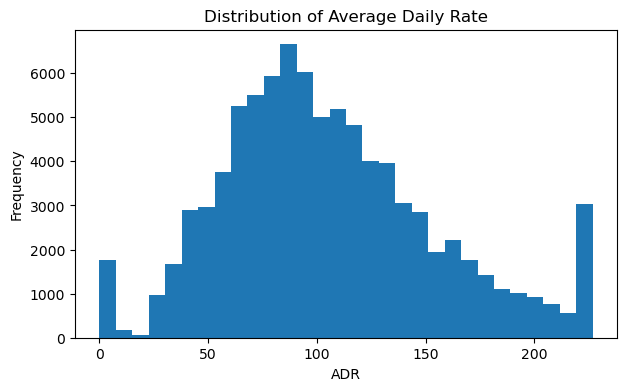

In [15]:
plt.figure(figsize=(7,4))
plt.hist(df["adr"], bins = 30)
plt.title("Distribution of Average Daily Rate")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

### 5.2 Lead Time

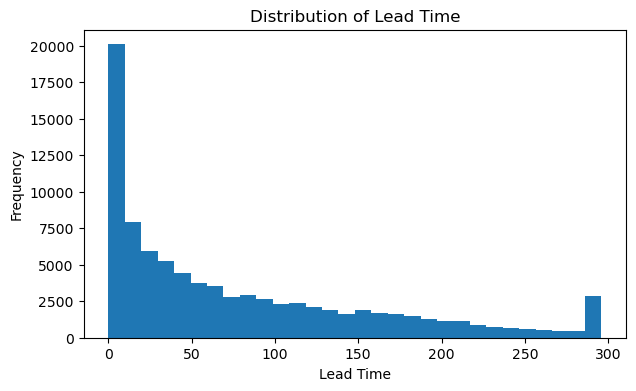

In [16]:
plt.figure(figsize=(7,4))
plt.hist(df["lead_time"], bins = 30)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")
plt.show()

### 5.3 Total Guests

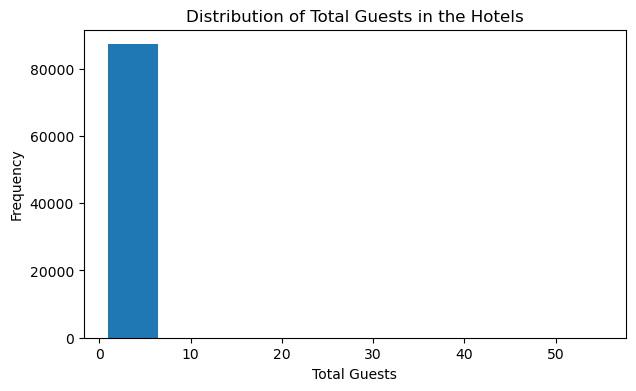

In [17]:
plt.figure(figsize=(7,4))
plt.hist(df["total_guests"], bins = 10)
plt.title("Distribution of Total Guests in the Hotels")
plt.xlabel("Total Guests")
plt.ylabel("Frequency")
plt.show()

### 5.4 Total Nights

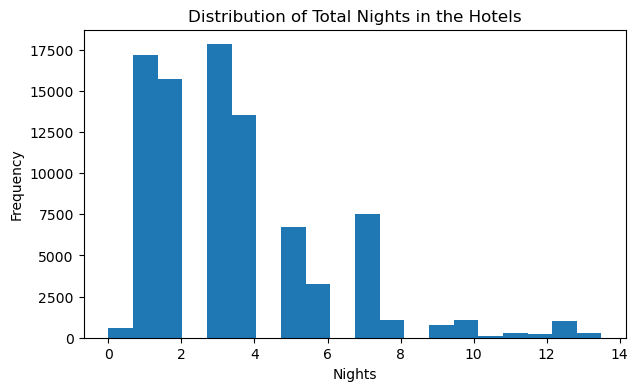

In [18]:
plt.figure(figsize=(7,4))
plt.hist(df["total_nights"], bins = 20)
plt.title("Distribution of Total Nights in the Hotels")
plt.xlabel("Nights")
plt.ylabel("Frequency")
plt.show()

## 6. Categorical Analysis

### 6.1 Hotel Type Distribution

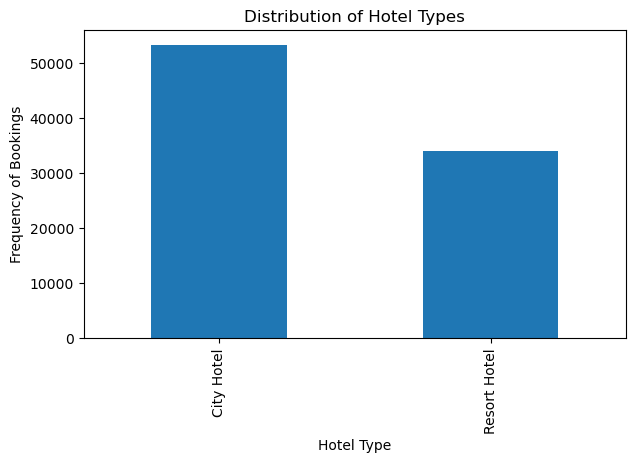

In [19]:
hotel_counts = df["hotel"].value_counts()

plt.figure(figsize=(7,4))
hotel_counts.plot(kind="bar")

plt.title("Distribution of Hotel Types")
plt.xlabel("Hotel Type")
plt.ylabel("Frequency of Bookings")

plt.show()

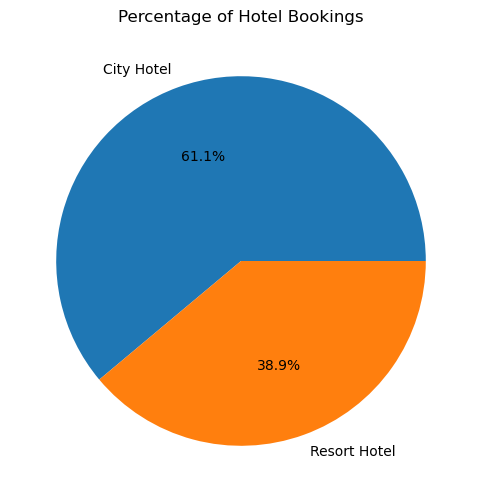

In [20]:
hotel_counts.plot(kind="pie", autopct = "%1.1f%%", figsize=(6,6))
plt.ylabel("")
plt.title("Percentage of Hotel Bookings")
plt.show()

### 6.2 Booking Status

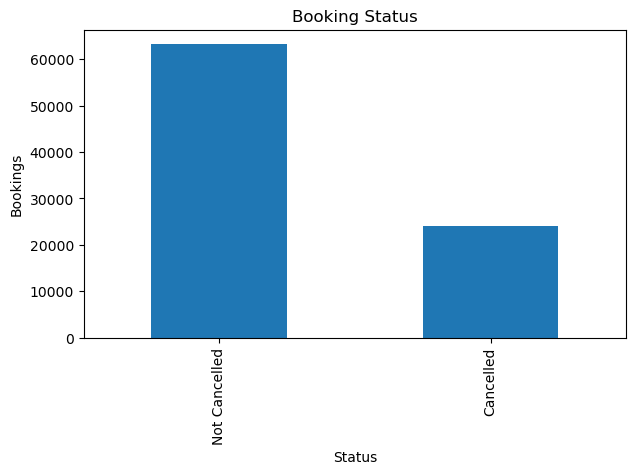

In [21]:
cancel = df["booking_status"].value_counts()

plt.figure(figsize=(7,4))
cancel.plot(kind="bar")

plt.title("Booking Status")
plt.xlabel("Status")
plt.ylabel("Bookings")

plt.show()

### 6.3 Type Of Customers 

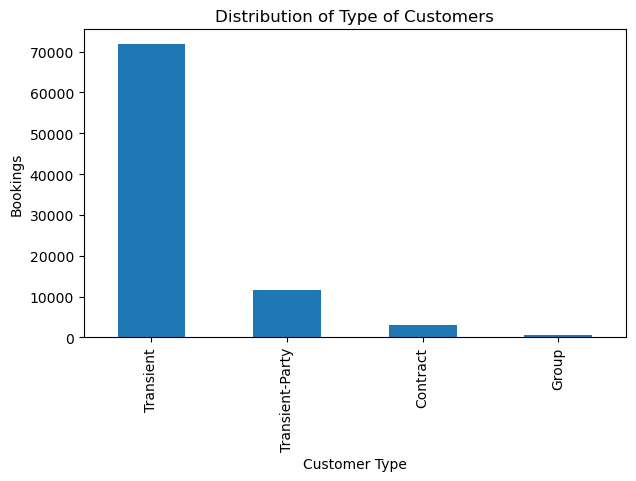

In [22]:
customer = df["customer_type"].value_counts()

plt.figure(figsize=(7,4))
customer.plot(kind="bar")

plt.title("Distribution of Type of Customers")
plt.xlabel("Customer Type")
plt.ylabel("Bookings")

plt.show()

### 6.4 Market Segment

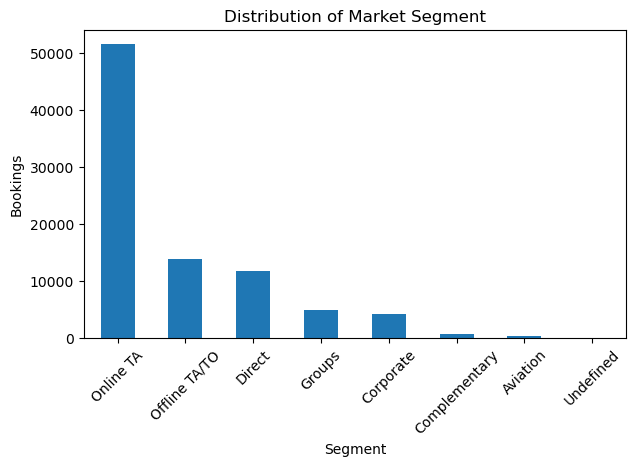

In [23]:
segment = df["market_segment"].value_counts()

plt.figure(figsize=(7,4))
segment.plot(kind="bar")

plt.title("Distribution of Market Segment")
plt.xlabel("Segment")
plt.ylabel("Bookings")
plt.xticks(rotation=45)

plt.show()

### 6.5 Meal Preference

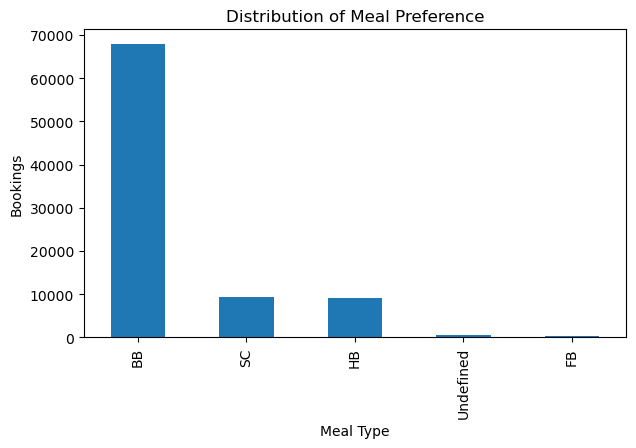

In [24]:
meal = df['meal'].value_counts()

plt.figure(figsize=(7,4))
meal.plot(kind="bar")

plt.title("Distribution of Meal Preference")
plt.xlabel("Meal Type")
plt.ylabel("Bookings")

plt.show()

### 6.6 Type Of Deposit

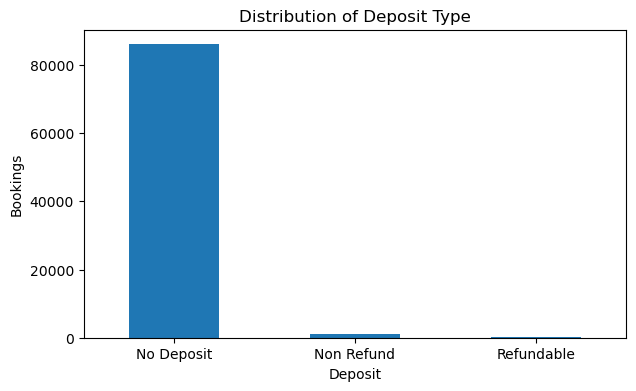

In [25]:
deposit = df["deposit_type"].value_counts()

plt.figure(figsize=(7,4))
deposit.plot(kind="bar")

plt.title("Distribution of Deposit Type")
plt.xlabel("Deposit")
plt.ylabel("Bookings")
plt.xticks(rotation=0)

plt.show()

### 6.7 Reserved Room Type

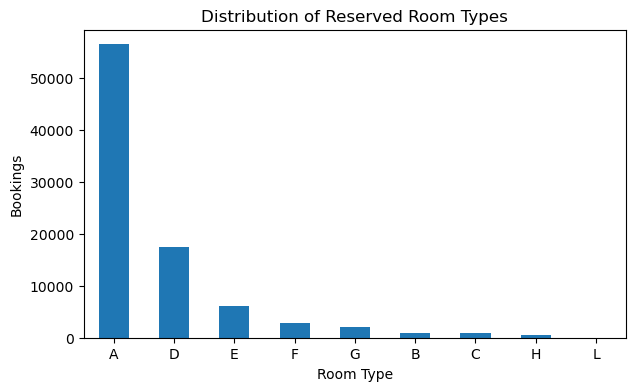

In [26]:
room = df["reserved_room_type"].value_counts()

plt.figure(figsize=(7,4))
room.plot(kind="bar")

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Room Type")
plt.ylabel("Bookings")
plt.xticks(rotation=0)

plt.show()

### 6.8 Top 10 Countries

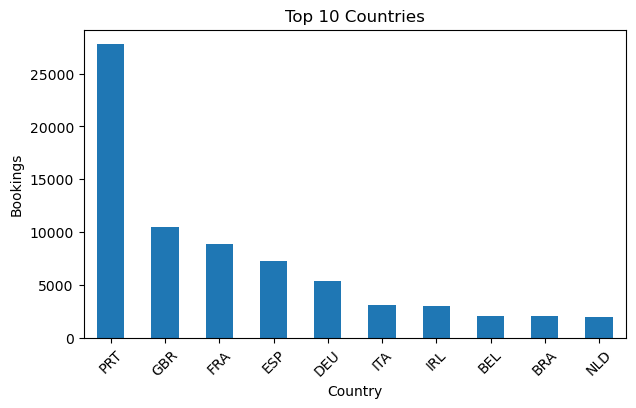

In [27]:
country = df["country"].value_counts().head(10)

plt.figure(figsize=(7,4))
country.plot(kind="bar")

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

## 7. Bivariate and Multivariate Analysis

### 7.1 ADR vs Hotel Type (Box Plot)

<Figure size 800x500 with 0 Axes>

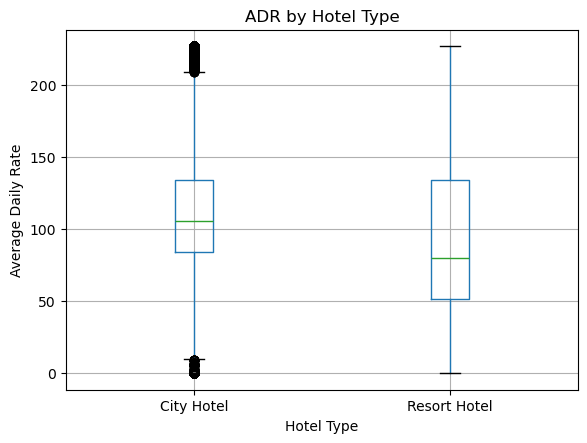

In [28]:
plt.figure(figsize=(8,5))

df.boxplot(column="adr", by="hotel")

plt.title("ADR by Hotel Type")
plt.suptitle("")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")
plt.show()

### 7.2 Lead Time vs Booking Status

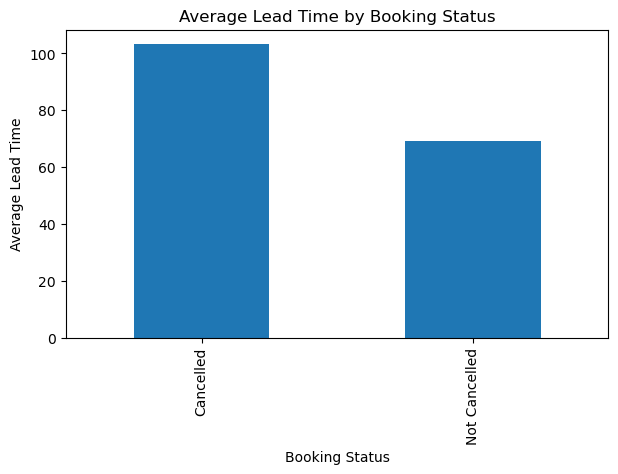

In [29]:
cancel_mean = df.groupby("booking_status")["lead_time"].mean()

plt.figure(figsize=(7,4))
cancel_mean.plot(kind="bar")

plt.title("Average Lead Time by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Lead Time")
plt.show()

### 7.3 ADR vs Total Guests

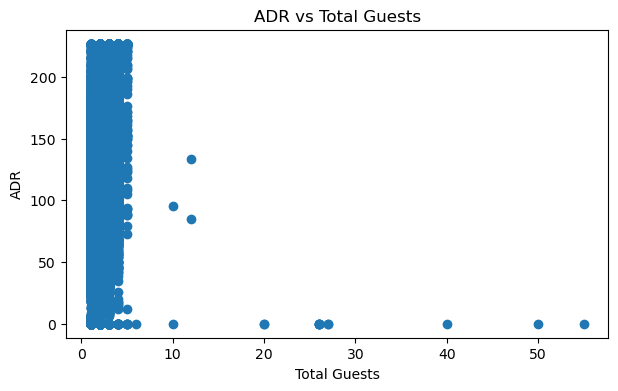

In [30]:
plt.figure(figsize=(7,4))

plt.scatter(df["total_guests"], df["adr"])

plt.title("ADR vs Total Guests")
plt.xlabel("Total Guests")
plt.ylabel("ADR")

plt.show()

### 7.4 ADR vs Total Nights

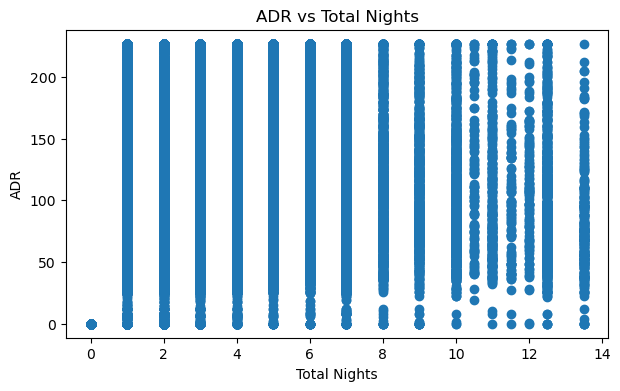

In [31]:
plt.figure(figsize=(7,4))

plt.scatter(df["total_nights"], df["adr"])

plt.xlabel("Total Nights")
plt.ylabel("ADR")

plt.title("ADR vs Total Nights")

plt.show()

### 7.5 Average ADR by Market Segment

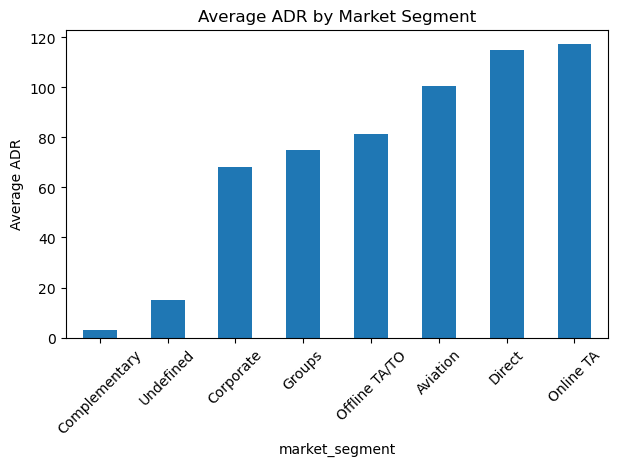

In [41]:
market = df.groupby("market_segment")["adr"].mean()

plt.figure(figsize=(7,4))
market.sort_values().plot(kind="bar")

plt.title("Average ADR by Market Segment")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.show()

### 7.6 Average ADR by Customer Type

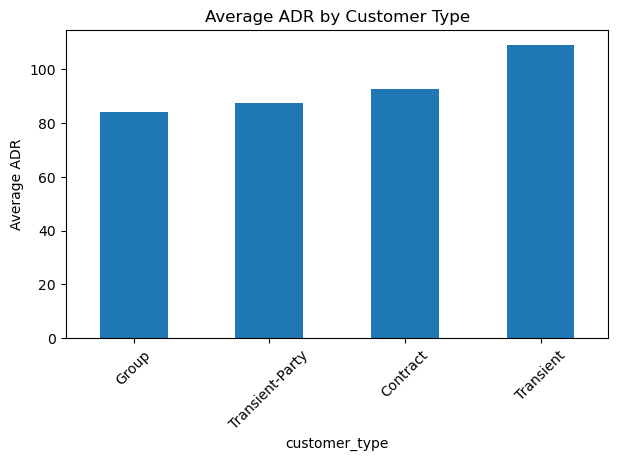

In [42]:
customer = df.groupby("customer_type")["adr"].mean()

plt.figure(figsize=(7,4))
customer.sort_values().plot(kind="bar")

plt.title("Average ADR by Customer Type")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.show()

### 7.7 Cancellation Rate by Hotel Type

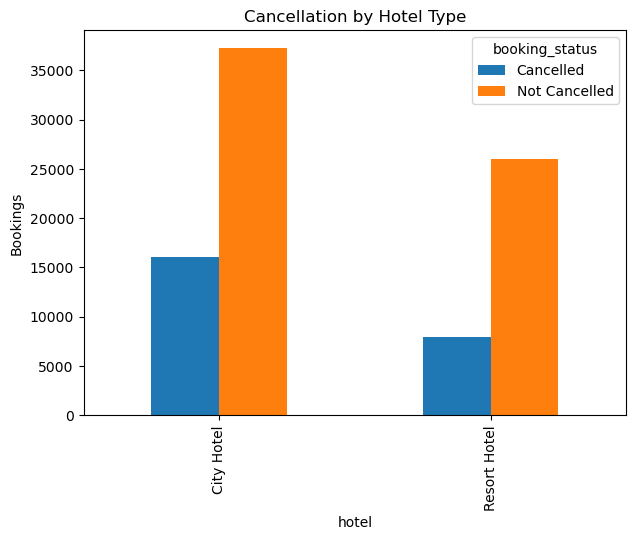

In [43]:
cancel = pd.crosstab(
    df["hotel"],
    df["booking_status"]
)

cancel.plot(kind="bar", figsize=(7,5))

plt.title("Cancellation by Hotel Type")

plt.ylabel("Bookings")

plt.show()

### 7.8 Correlation Heatmap of Dataset

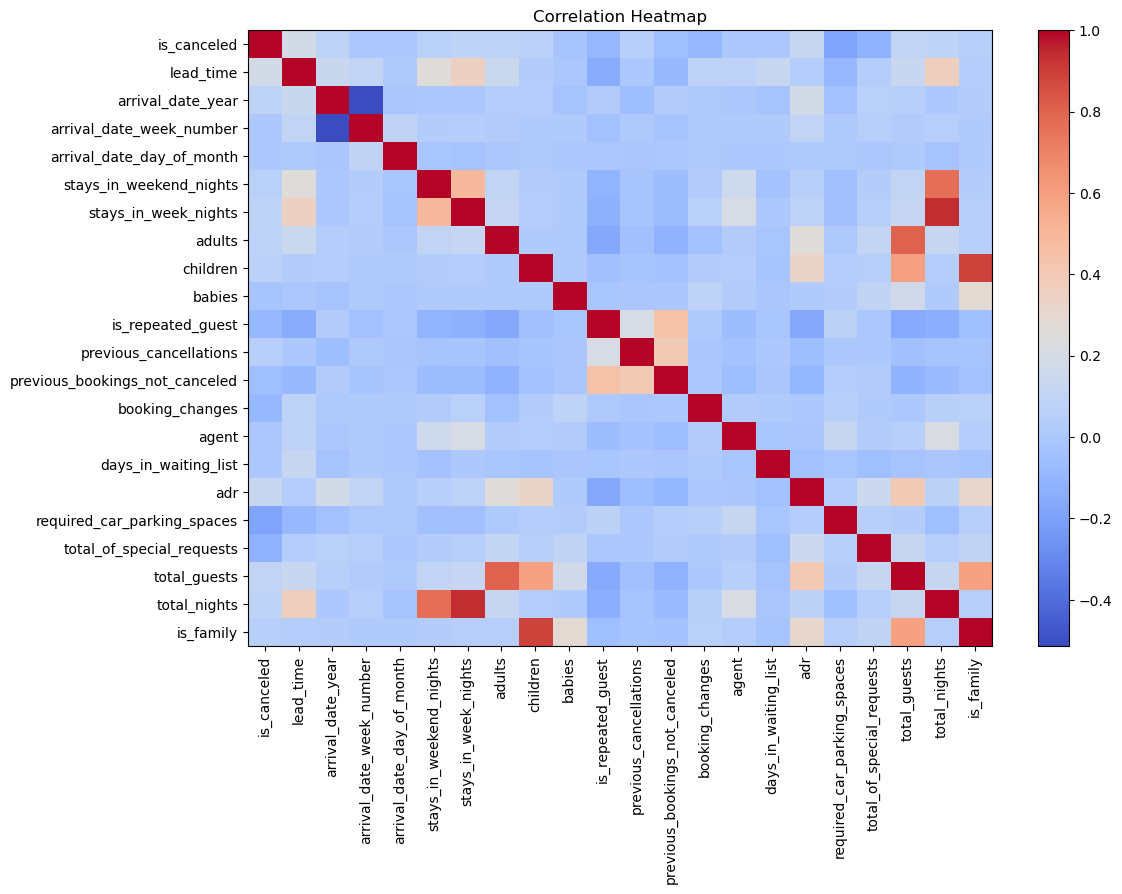

In [45]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

### 7.9 Correlation Matrix

In [46]:
corr.round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,is_family
is_canceled,1.00,0.19,0.09,0.00,0.01,0.06,0.09,0.08,0.07,-0.02,...,-0.05,-0.09,-0.00,0.00,0.14,-0.18,-0.12,0.10,0.09,0.05
lead_time,0.19,1.00,0.14,0.10,0.01,0.26,0.35,0.15,0.03,-0.00,...,-0.08,0.08,0.08,0.13,0.04,-0.09,0.04,0.13,0.36,0.04
arrival_date_year,0.09,0.14,1.00,-0.51,-0.01,0.00,0.00,0.04,0.04,-0.02,...,0.03,0.01,-0.00,-0.03,0.19,-0.04,0.06,0.05,0.00,0.04
arrival_date_week_number,0.00,0.10,-0.51,1.00,0.09,0.03,0.04,0.03,0.01,0.01,...,-0.02,0.01,0.02,0.01,0.11,0.01,0.05,0.03,0.04,0.02
arrival_date_day_of_month,0.01,0.01,-0.01,0.09,1.00,-0.02,-0.02,-0.00,0.02,-0.00,...,0.00,0.01,0.01,0.01,0.02,0.01,-0.00,0.01,-0.02,0.02
stays_in_weekend_nights,0.06,0.26,0.00,0.03,-0.02,1.00,0.49,0.10,0.03,0.01,...,-0.06,0.03,0.16,-0.03,0.05,-0.04,0.03,0.10,0.77,0.04
stays_in_week_nights,0.09,0.35,0.00,0.04,-0.02,0.49,1.00,0.12,0.04,0.02,...,-0.06,0.06,0.21,0.00,0.08,-0.05,0.04,0.11,0.94,0.04
adults,0.08,0.15,0.04,0.03,-0.00,0.10,0.12,1.00,0.02,0.02,...,-0.12,-0.04,0.03,-0.01,0.26,0.01,0.11,0.80,0.12,0.05
children,0.07,0.03,0.04,0.01,0.02,0.03,0.04,0.02,1.00,0.02,...,-0.03,0.03,0.04,-0.02,0.33,0.04,0.04,0.60,0.04,0.89
babies,-0.02,-0.00,-0.02,0.01,-0.00,0.01,0.02,0.02,0.02,1.00,...,-0.01,0.08,0.03,-0.01,0.02,0.03,0.09,0.17,0.02,0.28


## 8. Hypothesis Testing

### Test 1- Independent t-Test

In [50]:
from scipy.stats import ttest_ind

city = df[df["hotel"] == "City Hotel"]["adr"]
resort = df[df["hotel"] == "Resort Hotel"]["adr"]

t_stat, p_value = ttest_ind(city, resort, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("There is a significant difference in ADR between City Hotels and Resort Hotels.")
else:
    print("Fail to Reject the Null Hypothesis")

T-Statistic: 36.95693244012528
P-Value: 2.6384766695812286e-295
Reject the Null Hypothesis
There is a significant difference in ADR between City Hotels and Resort Hotels.


### Test 2: Chi-Square Test of Independence

In [51]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["hotel"], df["booking_status"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject the Null Hypothesis")
    print("Hotel type and booking cancellation are associated.")
else:
    print("Fail to Reject the Null Hypothesis")

Chi-Square: 452.57951987491407
P-value: 1.9803602767292085e-100
Reject the Null Hypothesis
Hotel type and booking cancellation are associated.
